# VocEd Lab 03 — Image Processing: Denoising & Morphology

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emilsar/VocEd/blob/main/03_image_processing.ipynb)

In Lab 02 we found the best possible threshold pair using Bayesian optimisation.  But the
optimiser was limited by the raw grayscale representation — if two classes overlap in
intensity, no threshold can cleanly separate them.

What if we **cleaned the image first** before thresholding?  Classical image processing
offers several tools: smoothing to remove noise, and morphological operations to clean up
the predicted mask.  This lab explores whether they actually help.

By the end of this lab you will be able to:
- Apply Gaussian blur and non-local means denoising to an image.
- Apply morphological opening and closing to a segmentation mask.
- Combine these steps into a configurable pipeline controlled by boolean toggles.
- Re-run Bayesian optimisation on the extended parameter space and compare results.
- Interpret a cumulative Dice comparison table across Labs 01–03.

## 0. Setup

In [1]:
!pip install scikit-optimize scikit-image --quiet

# Clone the repo
!git clone https://github.com/emilsar/VocEd.git
%cd VocEd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.8 MB/s eta 0:00:00
Cloning into 'VocEd'...
remote: Enumerating objects: 452, done.
remote: Counting objects: 100% (452/452), done.
remote: Compressing objects: 100% (194/194), done.
remote: Total 452 (delta 276), reused 425 (delta 257), pack-reused 0 (from 0)
Receiving objects: 100% (452/452), 25.24 MiB | 10.93 MiB/s, done.
Resolving deltas: 100% (276/276), done.
Updating files: 100% (408/408), done.
/content/VocEd


## 1. Load Data & Recreate the Train/Test Split

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

N = len(glob.glob('imagedata/X/*.npy'))
X = np.stack([np.load(f'imagedata/X/{i}.npy') for i in range(N)])
y = np.stack([np.load(f'imagedata/y/{i}.npy') for i in range(N)])

# Same split as Lab 02 — same seed, same indices
np.random.seed(42)
idx       = np.random.permutation(N)
train_idx = idx[:160]
test_idx  = idx[160:]

mask_cmap = ListedColormap(['black', 'steelblue', 'crimson'])
legend_patches = [
    mpatches.Patch(color='black',     label='0 — background'),
    mpatches.Patch(color='steelblue', label='1 — cytoplasm'),
    mpatches.Patch(color='crimson',   label='2 — nucleus'),
]
print(f'Loaded {N} images.  Train: {len(train_idx)}  Test: {len(test_idx)}')

Loaded 200 images.  Train: 160  Test: 40


## 2. Techniques Overview

We will test four classical image processing steps.  Each one is shown visually below with
a before/after comparison on image 7.

### Pre-threshold: image denoising

**Gaussian blur** — replaces each pixel with a weighted average of its neighbours.
Nearby pixels get higher weights; distant pixels get lower weights.  The result is a
smoother image with reduced noise, but also reduced sharpness.

**Non-local means** — instead of averaging a small neighbourhood, it searches the *entire*
image for patches that look similar to the current patch, and averages those.  This
preserves edges much better than Gaussian blur, but is slower to compute.

### Post-threshold: morphological operations

**Opening** (erode then dilate) — shrinks bright regions first (erosion), then grows them
back (dilation).  Small isolated bright blobs disappear because they get eroded away
entirely before dilation can restore them.

**Closing** (dilate then erode) — grows bright regions first, then shrinks them.  Small
holes inside bright regions get filled in by dilation before erosion can re-open them.

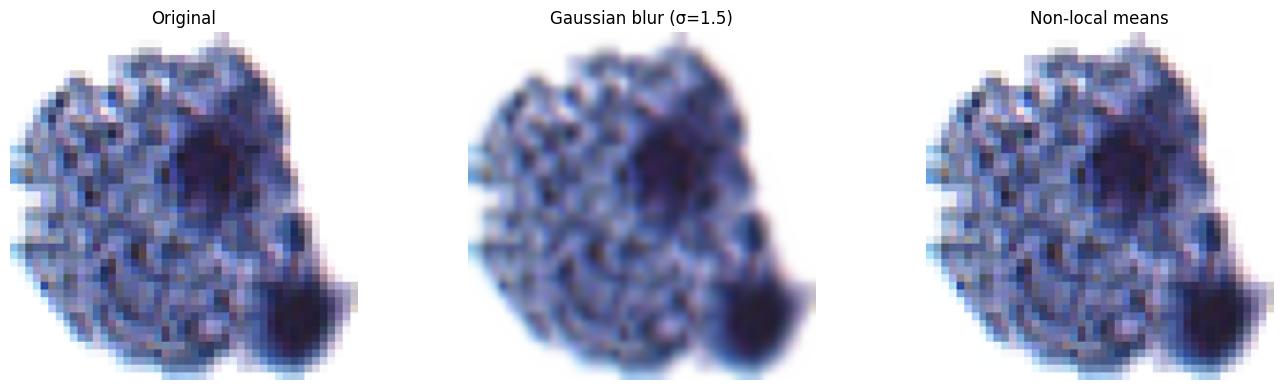

In [8]:
import skimage.filters as skf
import skimage.restoration as skr
import skimage.morphology as skm
from skimage.util import img_as_float32

IDX = 7
img7 = X[IDX]   # (3, 256, 256)

# Rearrange to (H, W, C) — skimage functions expect channel-last
img7_hwc = img7.transpose(1, 2, 0)   # (256, 256, 3)

# ── Gaussian blur ─────────────────────────────────────────────────────────────
# sigma controls the width of the blur kernel; higher = more blurring
# multichannel=True tells skimage that the last dimension is the colour channel
blurred = skf.gaussian(img7_hwc, sigma=2, channel_axis=-1)

# ── Non-local means ───────────────────────────────────────────────────────────
# h controls the filter strength; patch_size is the size of each image patch
# estimate_sigma gives a noise estimate to set h automatically
sigma_est = np.mean(skr.estimate_sigma(img7_hwc, channel_axis=-1))
nlm = skr.denoise_nl_means(img7_hwc, h=3 * sigma_est,
                             patch_size=8, patch_distance=10, channel_axis=-1)

# ── Show side by side ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img7_hwc);        axes[0].set_title('Original');         axes[0].axis('off')
axes[1].imshow(blurred);         axes[1].set_title('Gaussian blur (σ=1.5)'); axes[1].axis('off')
axes[2].imshow(np.clip(nlm, 0, 1)); axes[2].set_title('Non-local means'); axes[2].axis('off')
plt.tight_layout()
plt.show()

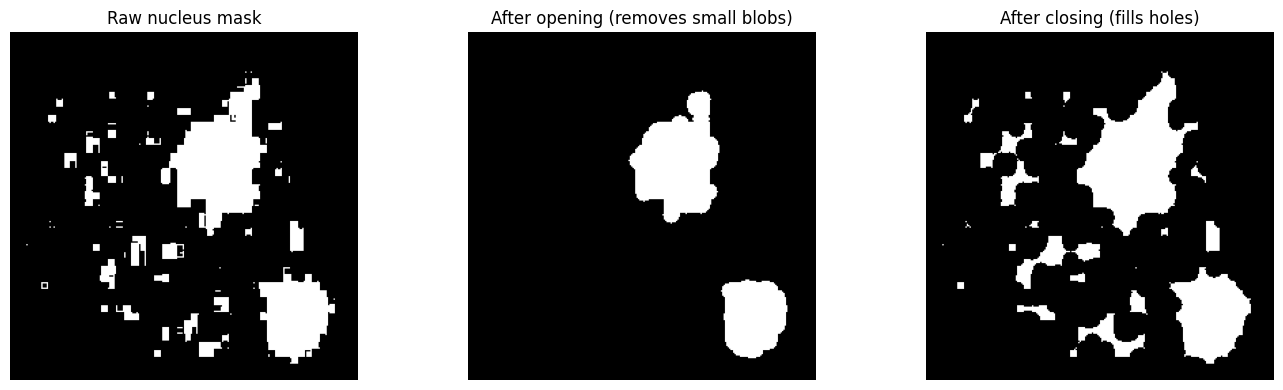

In [13]:
# ── Morphological operations on a nucleus mask ────────────────────────────────
# First, get the raw threshold prediction to use as a demo mask
def to_gray(img):
    return 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]

gray7  = to_gray(img7)
# Nucleus binary mask: 1 where predicted nucleus, 0 everywhere else
nuc_mask = (gray7 < 0.29).astype(bool)

# disk(3) creates a circular structuring element with radius 3 pixels
# — this is the "neighbourhood" used by erode/dilate
disk3 = skm.disk(6)

opened = skm.opening(nuc_mask, disk3)   # erode then dilate — removes small blobs
closed = skm.closing(nuc_mask, disk3)   # dilate then erode — fills small holes

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(nuc_mask, cmap='gray'); axes[0].set_title('Raw nucleus mask'); axes[0].axis('off')
axes[1].imshow(opened,   cmap='gray'); axes[1].set_title('After opening (removes small blobs)'); axes[1].axis('off')
axes[2].imshow(closed,   cmap='gray'); axes[2].set_title('After closing (fills holes)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## 3. The Configurable Pipeline

We now build a single `full_pipeline` function with boolean flags for each step.  Turning
a flag off (False) skips that step entirely and passes the image/mask through unchanged.
This makes it easy to ablate each component.

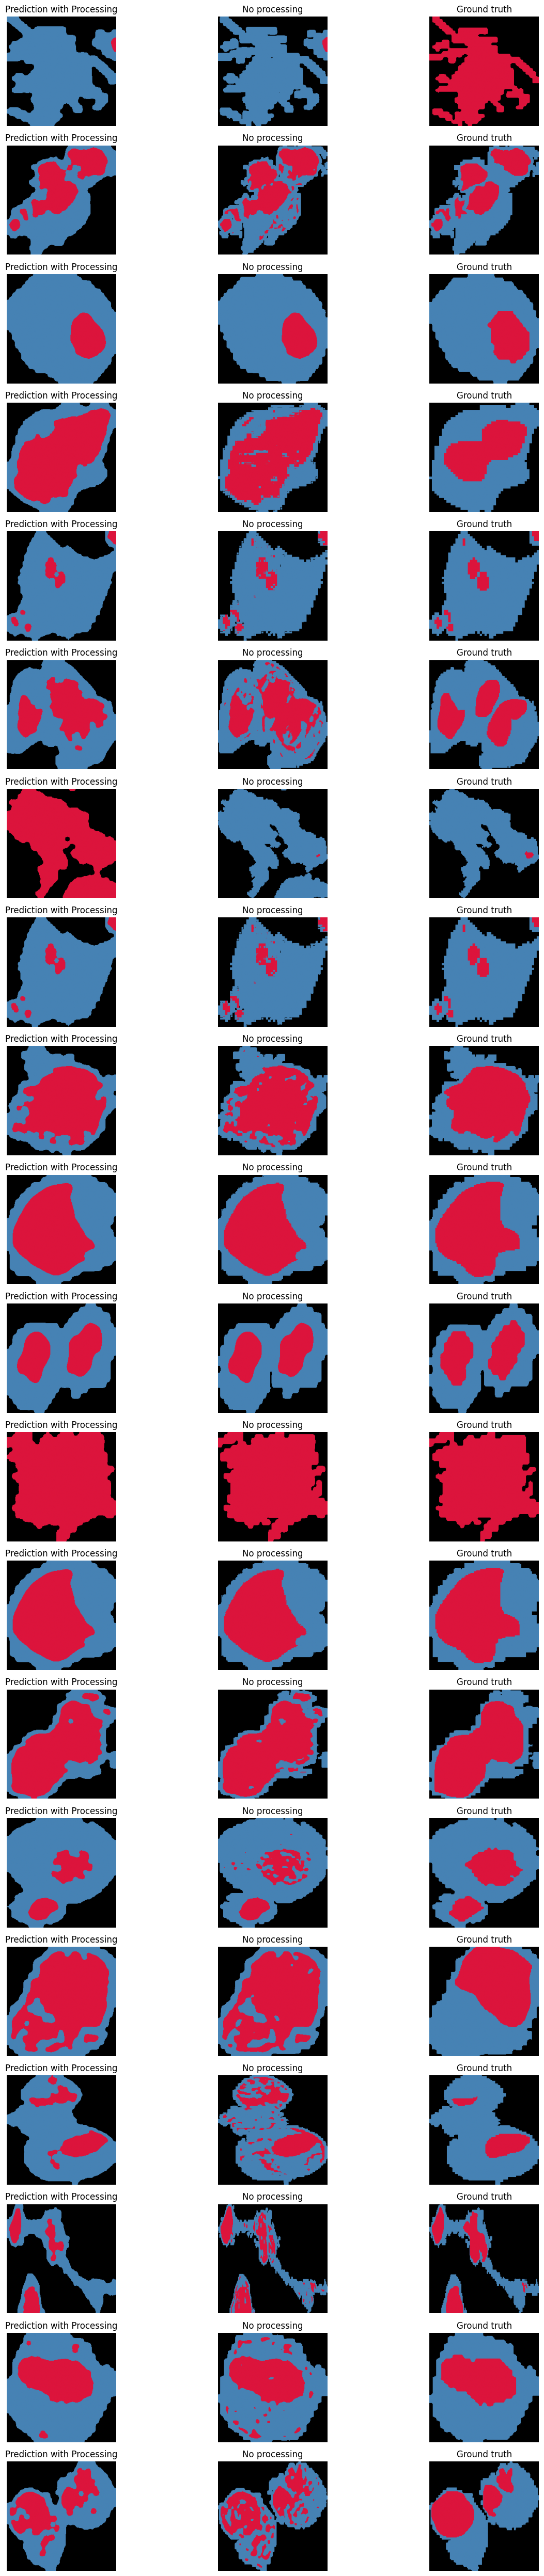

In [47]:

def full_pipeline(img, t_nucleus, t_background,
                  use_blur=True, use_nlm=True,
                  use_open=False, use_close=True,
                  blur_sigma=1.5, morph_radius=5):
    """
    Full segmentation pipeline with optional denoising and morphological steps.

    img            : (3, H, W) float32 image
    t_nucleus      : pixels darker than this → nucleus
    t_background   : pixels brighter than this → background
    use_blur       : apply Gaussian blur before thresholding
    use_nlm        : apply non-local means before thresholding
    use_open       : apply morphological opening after thresholding
    use_close      : apply morphological closing after thresholding
    blur_sigma     : sigma for Gaussian blur
    morph_radius   : radius of the disk structuring element
    """
    img_hwc = img.transpose(1, 2, 0)   # convert to (H, W, C) for skimage

    # ── Step 1: optional pre-threshold denoising ──────────────────────────────
    if use_blur:
        img_hwc = skf.gaussian(img_hwc, sigma=blur_sigma, channel_axis=-1)

    if use_nlm:
        sig = np.mean(skr.estimate_sigma(img_hwc, channel_axis=-1))
        img_hwc = skr.denoise_nl_means(img_hwc, h=0.8 * sig,
                                        patch_size=5, patch_distance=6,
                                        channel_axis=-1)

    # ── Step 2: grayscale + threshold ─────────────────────────────────────────
    gray = 0.299 * img_hwc[:,:,0] + 0.587 * img_hwc[:,:,1] + 0.114 * img_hwc[:,:,2]
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]    = 1

    # ── Step 3: optional post-threshold morphology ────────────────────────────
    if use_open or use_close:
        disk = skm.disk(morph_radius)
        for cls in [1, 2]:                          # process cytoplasm and nucleus separately
            cls_mask = (pred == cls).astype(bool)

            if use_open:
                cls_mask = skm.opening(cls_mask, disk)

            if use_close:
                cls_mask = skm.closing(cls_mask, disk)

            pred[pred == cls] = 0                   # clear the class pixels
            pred[cls_mask]    = cls                 # write back the cleaned mask

    return pred


# Sanity check: run pipeline on image 7 with no optional steps

def sanity():
  fig, axes = plt.subplots(20, 3, figsize=(14, 50))

  for i in range(20):
      rng = np.random.default_rng()
      idx = rng.choice(len(train_idx))

      axes[i, 0].imshow(full_pipeline(X[idx], t_nucleus=0.39, t_background=0.99,
                                      use_blur=False, use_nlm=False,
                                      use_open=False, use_close=False,
                                      blur_sigma=1.5, morph_radius=5), cmap=mask_cmap), cmap=mask_cmap)
      axes[i, 0].set_title("Prediction with No Processing')
      axes[i, 0].axis('off')

      axes[i, 1].imshow(full_pipeline(X[idx], t_nucleus=0.39, t_background=0.99,
                                      use_blur=True, use_nlm=True,
                                      use_open=False, use_close=True,
                                      blur_sigma=1.5, morph_radius=5), cmap=mask_cmap)
      axes[i, 1].set_title('Prediction With Processing')
      axes[i, 1].axis('off')

      axes[i, 2].imshow(y[idx], cmap=mask_cmap)
      axes[i, 2].set_title('Ground truth')
      axes[i, 2].axis('off')

  plt.tight_layout()
  plt.show()

sanity()

## 4. Bayesian Optimisation with All Steps Enabled

We now run Bayesian optimisation over a larger parameter space that includes all optional
steps turned on.  We treat the five continuous parameters — `t_nucleus`, `t_background`,
`blur_sigma`, and `morph_radius` — as the search variables, with the boolean flags fixed
to `True` (all steps enabled).  This tests whether the combined pipeline can beat pure
threshold optimisation.

In [16]:
from skopt import gp_minimize
from skopt.space import Real, Integer

def dice_score(pred, target, cls):
    pred_mask   = (pred   == cls)
    target_mask = (target == cls)
    intersection = (pred_mask & target_mask).sum()
    denom = pred_mask.sum() + target_mask.sum()
    return 1.0 if denom == 0 else 2 * intersection / denom


def mean_dice_pipeline(indices, t_nucleus, t_background,
                        use_blur, use_nlm, use_open, use_close,
                        blur_sigma=1.5, morph_radius=3):
    """Mean Dice over a list of image indices using the full pipeline."""
    scores = []
    for i in indices:
        pred = full_pipeline(X[i], t_nucleus, t_background,
                             use_blur=use_blur, use_nlm=use_nlm,
                             use_open=use_open, use_close=use_close,
                             blur_sigma=blur_sigma, morph_radius=morph_radius)
        d = (dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2
        scores.append(d)
    return np.mean(scores)


# ── Objective: optimise over 4 continuous parameters, all steps enabled ───────
def objective_full(params):
    t_nuc, t_bg, sigma, radius = params
    return -mean_dice_pipeline(
        train_idx, t_nuc, t_bg,
        use_blur=True, use_nlm=False,   # NLM is slow; use blur for the automated search
        use_open=True, use_close=True,
        blur_sigma=sigma, morph_radius=int(radius)
    )


search_space_full = [
    Real(0.10, 0.70, name='t_nucleus'),
    Real(0.50, 0.99, name='t_background'),
    #Real(0.5,  3.0,  name='blur_sigma'),
    #Real(1,    5,    name='morph_radius'),
]

print('Running Bayesian optimisation with full pipeline (50 evals)...')
result_full = gp_minimize(
    func=objective_full,
    dimensions=search_space_full,
    n_calls=50,
    n_initial_points=10,
    random_state=42,
    verbose=False,
)
print('Done.')

best_nuc_full, best_bg_full, best_sigma, best_radius = result_full.x
print(f'Best params: t_nuc={best_nuc_full:.4f}  t_bg={best_bg_full:.4f}  '
      f'sigma={best_sigma:.2f}  radius={best_radius:.1f}')
print(f'Train Dice: {-result_full.fun:.4f}')

Running Bayesian optimisation with full pipeline (50 evals)...
Done.
Best params: t_nuc=0.4122  t_bg=0.9558  sigma=2.43  radius=2.6
Train Dice: 0.7848


## 5. Cumulative Comparison Table — Labs 01, 02, 03

We record the test-set Dice for each method so far.  We will extend this table in every
subsequent lab.

In [17]:
# Lab 01 baseline (hand-picked)
def segment_plain(img, t_nucleus, t_background):
    gray = to_gray(img)
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]    = 1
    return pred

def test_dice(pred_fn):
    scores = []
    for i in test_idx:
        pred = pred_fn(i)
        d = (dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2
        scores.append(d)
    return np.mean(scores)

# Lab 01: hand-picked thresholds
d_lab01 = test_dice(lambda i: segment_plain(X[i], 0.45, 0.85))

# Lab 02: Bayesian-optimised thresholds (best values from Lab 02)
# (re-run the Lab 02 optimisation quickly with n_calls=50 to get the same result)
def objective_lab02(params):
    t_nuc, t_bg = params
    scores = []
    for i in train_idx:
        pred = segment_plain(X[i], t_nuc, t_bg)
        d = (dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2
        scores.append(d)
    return -np.mean(scores)

from skopt.space import Real
from skopt import gp_minimize

res02 = gp_minimize(objective_lab02,
                    [Real(0.10, 0.70), Real(0.50, 0.99)],
                    n_calls=50, n_initial_points=10, random_state=42, verbose=False)
d_lab02 = test_dice(lambda i: segment_plain(X[i], res02.x[0], res02.x[1]))

# Lab 03: full pipeline with optimised params
d_lab03 = test_dice(
    lambda i: full_pipeline(X[i],
                            best_nuc_full, best_bg_full,
                            use_blur=True, use_nlm=False,
                            use_open=True, use_close=True,
                            blur_sigma=best_sigma,
                            morph_radius=int(best_radius))
)

print('=' * 52)
print(f'{"Method":<30}  {"Test Dice":>10}')
print('-' * 52)
print(f'{"Lab 01 — hand-picked thresholds":<30}  {d_lab01:10.4f}')
print(f'{"Lab 02 — Bayesian opt thresholds":<30}  {d_lab02:10.4f}')
print(f'{"Lab 03 — Bayesian opt + pipeline":<30}  {d_lab03:10.4f}')
print('=' * 52)

Method                           Test Dice
----------------------------------------------------
Lab 01 — hand-picked thresholds      0.7120
Lab 02 — Bayesian opt thresholds      0.7881
Lab 03 — Bayesian opt + pipeline      0.7929


## Wrap-up

**Key takeaways:**
- Denoising and morphology can help at the margins — they reduce noise artefacts and clean
  up ragged mask boundaries.
- But the improvements are small.  The fundamental bottleneck is that two classes overlap
  in grayscale intensity; no amount of pre-processing fully resolves that.
- In the next lab we move past grayscale entirely: we will treat each pixel as a vector of
  **3 colour values** and train a classifier to separate them.

---

## Group Exercise — Ablation Study

An *ablation study* measures how much each component of a system contributes by removing
it and measuring the drop in performance.

Your group will test the pipeline on **5 images** (`test_idx[0:5]`) with each toggle.
Use the optimised thresholds from Lab 02 (`res02.x[0]` and `res02.x[1]`) throughout.

| Person | Toggle to test |
|---|---|
| A | `use_blur=True`, all others `False` |
| B | `use_open=True`, all others `False` |
| C | `use_close=True`, all others `False` |

For each toggle, record the mean Dice on those 5 images and the Dice delta vs the baseline
(no processing).  Share results and discuss: which step helps most, and why?